<a href="https://colab.research.google.com/github/Pallavi20004/Demo/blob/main/KMeans_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Import Required Libraries

In [ ]:
from keras.datasets import mnist
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import numpy as np
from scipy import sparse
from sklearn.metrics import accuracy_score


Step 2: Load the Dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()


Step 3: Check Dataset Shape

In [ ]:
print(x_train.shape)  # (60000, 28, 28)
print(x_test.shape)   # (10000, 28, 28)
print(y_train.shape)  # (60000,)
print(y_test.shape)   # (10000,)


(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


Step 4: Visualize Some MNIST Images

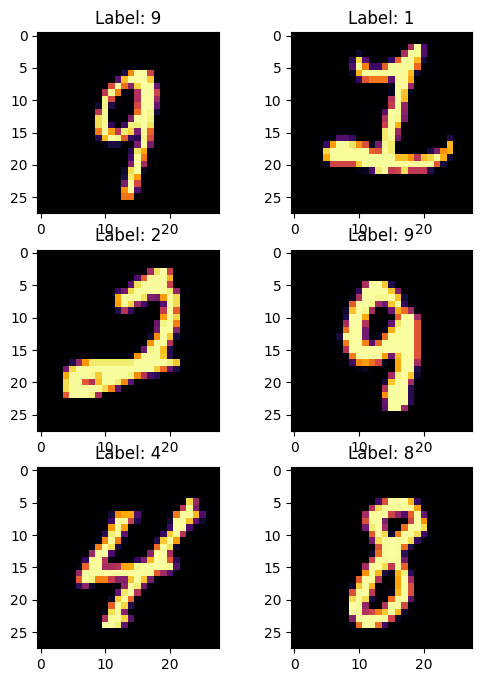

In [ ]:
plt.figure(figsize=(6, 8))
indices = np.random.choice(len(x_train), 6, replace=False)

for i, idx in enumerate(indices):
    plt.subplot(3, 2, i + 1)
    plt.imshow(x_train[idx], cmap='inferno')
    plt.title(f'Label: {y_train[idx]}')
plt.show()


Step 5: Data Preprocessing

In [ ]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


In [ ]:
X_train = x_train.reshape(len(x_train), -1)
X_test = x_test.reshape(len(x_test), -1)

print(X_train.shape)  # (60000, 784)
print(X_test.shape)   # (10000, 784)


(60000, 784)
(10000, 784)


Step 6: Build the KMeans Model

In [ ]:
total_clusters = len(np.unique(y_test))

kmeans = MiniBatchKMeans(n_clusters=total_clusters)

X_train_sparse = sparse.csr_matrix(X_train)

kmeans.fit(X_train_sparse)

print(kmeans.labels_)


[7 4 1 ... 9 0 9]


Step 7: Map Cluster Labels to Actual Digits

In [ ]:
def retrieve_info(cluster_labels, y_true):
    reference_labels = {}
    for i in range(len(np.unique(cluster_labels))):
        index = np.where(cluster_labels == i, 1, 0)
        most_common = np.bincount(y_true[index == 1]).argmax()
        reference_labels[i] = most_common
    return reference_labels

reference_labels = retrieve_info(kmeans.labels_, y_train)
print(reference_labels)


{0: np.int64(6), 1: np.int64(9), 2: np.int64(1), 3: np.int64(7), 4: np.int64(0), 5: np.int64(2), 6: np.int64(1), 7: np.int64(3), 8: np.int64(4), 9: np.int64(8)}


Step 8: Assign Labels to Each Image

In [ ]:
number_labels = np.zeros(len(kmeans.labels_))

for i in range(len(kmeans.labels_)):
    number_labels[i] = reference_labels[kmeans.labels_[i]]

print("Predicted labels (first 20):", number_labels[:20].astype('int'))
print("Actual labels    (first 20):", y_train[:20])


Predicted labels (first 20): [3 0 9 1 4 2 1 3 1 4 3 1 3 6 1 7 2 8 6 8]
Actual labels    (first 20): [5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9]


Step 9: Accuracy Calculation

In [ ]:
accuracy = accuracy_score(number_labels, y_train)
print("Accuracy:", accuracy)


Accuracy: 0.6083333333333333
